In [1]:
try:
    import smolgp
except ImportError:
    %pip install -q smolgp

try:
    import tinygp
except ImportError:
    %pip install -q tinygp

import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt

key = jax.random.PRNGKey(0)
jax.config.update("jax_enable_x64", True)
mpl.rc('font', family='sans serif', size=16)

# Animation embedding
from pathlib import Path

from IPython.display import HTML


(sample)=

# Sampling from a Gaussian Process

Sampling a GP is the act of making random draws from either the GP prior, or the posterior if the GP was conditioned on observed data. Each draw from the GP represents a possible continuous realization of the process, $f(t)$.

With a `GaussianProcess` object defined, one can draw samples from its prior using the `GaussianProcess.sample()` function (analagous to [`tinygp`](http://tinygp.readthedocs.io/en/latest/tutorials/intro.html#sampling)). If the GP has already been conditioned, then these samples are instead drawn from the posterior. Each call to `sample` returns a self-consistent draw (that is, one joint sample of the multivariate Gaussian) sampled at the timesteps of the data (i.e., at `X` which was passed into the `GaussianProcess` object), unless one passes an `X_test` argument to `sample` in which case the draw is sampled at these (arbitrary) timestamps instead.

:::{admonition} A note about seeding the same sample draw
:class: note dropdown
`sample()` is a deterministic function of its `key` as well as the shape and values of the `shape` and `X_test` arguments, if specified. As such, if either `shape` or `X_test` change, a reused JAX key does **not** "seed" the same _draw_ from the GP; a different underlying realization will be returned. This is because, internally, how many random numbers get drawn (and in what order) depends on the size and chronological order of the state trajectory being simulated, which depends on the shape of `X` (or `X_test`) and its precise values (and hence, orderings).

If you want one coherent realization of the process queried multiple ways at once, such as a dense grid *and* a handful of exposure-integrated windows sampled from the same random draw (like in the examples below), then you will need to combine every point you want into a single `X_test` and call `sample()` once.
:::

## Sampling from a state space GP

Recall from {ref}`introssm` that a state space GP reinterprets $f(t)$ as the solution to a linear SDE, solved recursively state-to-state as

\begin{align}
\boldsymbol{x}_{k+1} = \boldsymbol{A}_k \boldsymbol{x}_k + \boldsymbol{q}_k, \quad \boldsymbol{q}_k \sim N(\boldsymbol{0}, \boldsymbol{Q}_k).
\end{align}

Sampling is nothing more than actually *simulating* this recursion forward in time:
1. Draw an initial state $\boldsymbol{x}_0 \sim N(\boldsymbol{0}, \boldsymbol{P}_\infty)$ (zero prior mean),
2. Draw a fresh realization of the process noise $\boldsymbol{q}_k$ and step forward to sample the next state,
3. Repeat #2 until all states are sampled.

This is exactly like simulating one possible future of a physical system given random driving noise (e.g., a damped and driven oscillator's position and velocity). Where the Kalman filter (and RTS smoother) track the overall *distribution* (mean and covariance) over all possible trajectories, sampling draws one realization from that distribution.

For a conditioned (posterior) GP, we include the data as states in the simulation, whether or not the sampling locations include them. Then, we draw a prior sample using  the chronological forward pass of steps 1-3 through the data and sample states. Then, at the data states, we apply Matheron's rule (see [Wilson et al. 2020](https://arxiv.org/abs/2002.09309)):

4. At each state with observed data, compare the drawn sample (projected through the observation matrix, plus a fresh draw of observation noise) to the real data, forming a residual at each such state. Run the whole sequence of residuals through the ordinary Kalman/RTS conditioning machinery (a Kalman update pass followed by RTS smoothing) to correct the sampled trajectory at the data states. Then, correct the sampled trajectory at the non-data states with the standard predict machinery.

Like conditioning, sampling in the state space is thus also $\mathcal{O}(N)$ and circumvents the need to construct the full $N\times N$ covariance matrix (or its Cholesky factor), as in needed in the traditional GP approach.

:::{admonition} References for sampling in the state space
:class: seealso dropdown
The algorithm used by {meth}`smolgp.GaussianProcess.sample` appears independently in the literature under different names:
- Doucet, ["A Note on Efficient Conditional Simulation of Gaussian Distributions"](https://www.stats.ox.ac.uk/~doucet/doucet_simulationconditionalgaussian.pdf)
- Durbin & Koopman (2002), ["A simple and efficient simulation smoother for state space time series analysis"](https://doi.org/10.1093/biomet/89.3.603), *Biometrika* 89(3):603-616
- Wilson et al. (2020/2021), ["Efficiently sampling functions from Gaussian process posteriors"](https://arxiv.org/abs/2002.09309) / ["Pathwise Conditioning of Gaussian Processes"](https://arxiv.org/abs/2011.04026)
:::

## Drawing samples from the prior

Drawing samples from the prior is the act of drawing $f(t) \sim \text{GP}(m_0(t), k(t,t'))$, where $m_0$ is the prior mean function of the GP (often zero) and $k(t,t')$ is the kernel function.

### State space sampling (from the prior), visualized:

In [2]:
# Define a damped, driven oscillator for this example
sigma = 2.1               # oscillation amplitude
omega = 2 * jnp.pi / 60.  # oscillation frequency (60 sec period)
quality = 5.3             # quality factor
kernel_smol = smolgp.kernels.SHO(omega, quality, sigma)

In [3]:
HTML(Path("sample_anim/sample_animation.html").read_text())

Here we demonstrate making multiple independent draws in the same call:

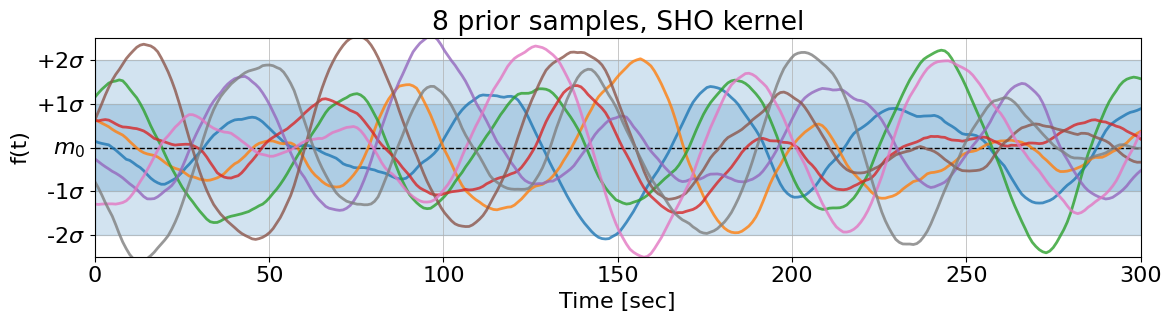

In [4]:
t = jnp.linspace(0, 300, 300)
gp = smolgp.GaussianProcess(kernel_smol, X=t, noise=jnp.full_like(t, 0.0))

# Draw samples from the prior distribution of the GP
key, subkey = jax.random.split(key)
samples = gp.sample(subkey, shape=(8,))  # 8 independent draws in one call

# Also draw the prior distribution itself
prior_std = jnp.sqrt(jnp.diag(kernel_smol(t, t)))

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.fill_between(t, -1, 1, color='C0', alpha=0.2)
ax.fill_between(t, -2, 2, color='C0', alpha=0.2)
ax.axhline(0, color='k', lw=1, ls='--', alpha=1)
for i in range(8):
    ax.plot(t, samples[:, i] / prior_std, lw=2, alpha=0.8)
ax.set(xlabel="Time [sec]", ylabel="f(t)", xlim=(0, 300), ylim=(-2.5, 2.5), title="8 prior samples, SHO kernel")
ax.set_yticks([-2, -1, 0, 1, 2], labels=[r'-2$\sigma$', r'-1$\sigma$', r'$m_0$', r'+1$\sigma$', r'+2$\sigma$'])
ax.grid(lw=0.5); fig.tight_layout()

## Drawing samples from the posterior

Drawing samples from the posterior is the act of drawing $f(t) \sim \text{GP}(\mu_{GP}(t), \Sigma_{GP}(t))$, where $\mu_{GP}(t)$ and $\Sigma_{GP}(t)$ are the (continuous-over-all-points) conditioned mean and variance given the data (Eq. {eq}`gp_mean_cov` in {ref}`introssm`).

### State space sampling (from the posterior), visualized:

In [5]:
HTML(Path("sample_anim/posterior_sample_animation.html").read_text())

First, we need to some data...

In [6]:
from scipy.interpolate import make_smoothing_spline

kernel_tiny = tinygp.kernels.quasisep.SHO(omega, quality, sigma)

# Generate a true signal from which to draw observations
def get_true_process(tmin=0, tmax=300, dt=1):
    t_dense = jnp.arange(tmin, tmax, dt)
    true_gp = tinygp.GaussianProcess(kernel_tiny, t_dense)
    y_dense = true_gp.sample(key=jax.random.PRNGKey(32))
    return t_dense, make_smoothing_spline(t_dense, y_dense, lam=dt / 6)

t_true, f = get_true_process()

t_obs = jnp.sort(jax.random.uniform(subkey, (30,), minval=0, maxval=300))
yerr = 0.3
y_obs = f(t_obs) + yerr * jax.random.normal(subkey, t_obs.shape)

...which we can use to condition a GP:

In [7]:
gp_obs = smolgp.GaussianProcess(kernel_smol, X=t_obs, noise=yerr**2)
_, condgp = gp_obs.condition(y_obs)

Now, draw samples at a dense grid of test points, passed via `X_test`. We'll compare these to the predictive mean and covariance to show they are indeed Gaussian distributed.

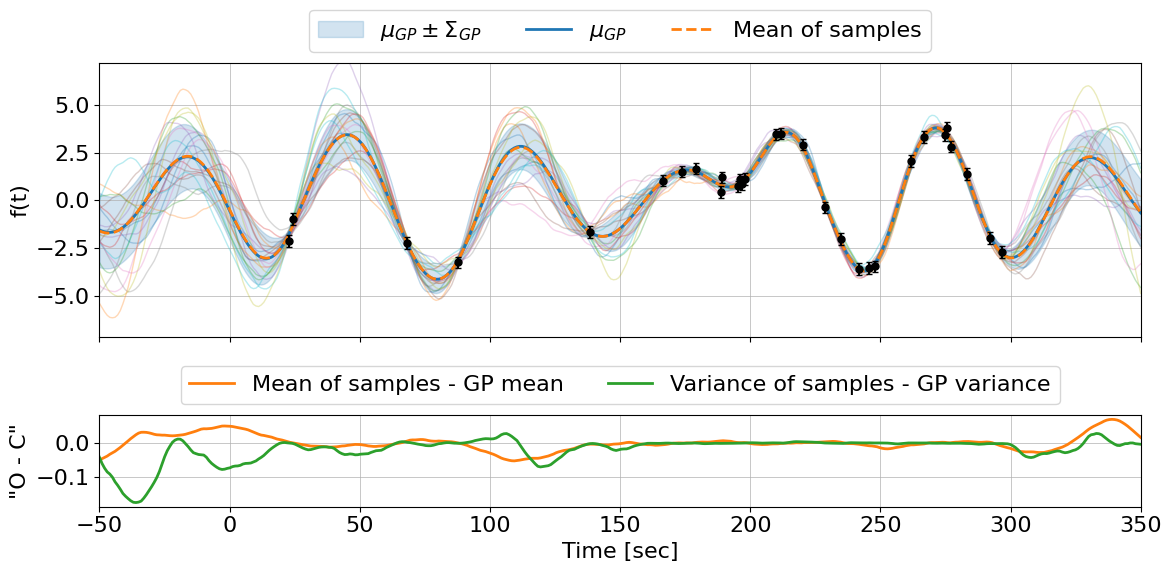

In [8]:
# A dense, evenly-spaced grid spanning before, between, and after the data
t_test = jnp.linspace(-50.0, 350.0, 400)

# Sample from the posterior
post_samples = condgp.sample(subkey, shape=(3000,), X_test=t_test)  # (400, 3000)

# Compare to the posterior predictive mean and variance
mean_emp = jnp.mean(post_samples, axis=-1)
var_emp = jnp.var(post_samples, axis=-1, ddof=1)
mu_pred, var_pred = condgp.predict(t_test, return_var=True)
sd_pred = jnp.sqrt(var_pred)

# Plot
fig, (ax, rax) = plt.subplots(2, 1,figsize=(12,6), sharex=True, gridspec_kw=dict(height_ratios=[3, 1]))
for i in range(20):
    ax.plot(t_test, post_samples[:, i], alpha=0.3, lw=1)
ax.fill_between(t_test, mu_pred - sd_pred, mu_pred + sd_pred, color="C0", alpha=0.2, label=r"$\mu_{GP} \pm \Sigma_{GP}$")
ax.plot(t_test, mu_pred, color="C0", lw=2, label=r"$\mu_{GP}$")
ax.plot(t_test, mean_emp, color="C1", lw=2, ls="--", label="Mean of samples")
ax.errorbar(t_obs, y_obs, yerr=yerr, fmt="o", color="k", ms=5, capsize=2, zorder=5)
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1)); 
rax.plot(t_test, mean_emp - mu_pred, color="C1", lw=2, ls="-", label="Mean of samples - GP mean")
rax.plot(t_test, var_emp - var_pred, color="C2", lw=2, ls="-", label="Variance of samples - GP variance")
rax.legend(ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1));
ax.set(ylabel="f(t)",ylim=[-7.2, 7.2]); ax.grid(lw=0.5); rax.grid(lw=0.5);
rax.set(xlabel="Time [sec]", ylabel=r'"O - C"', xlim=[t_test.min(), t_test.max()])
fig.tight_layout()

## Drawing samples with exposure times

:::{admonition} How does the math change to draw exposure-integrated samples?
:class: note tip
Recall that to condition an integrated measurement requires augmenting the state with an "integral" state to accumulate during an exposure (see {ref}`integrated`). Simulating an exposure likewise needs an integral dimension, reset to zero at the exposure start and read out at the exposure end. Like with multiple instruments, a request to draw samples at exposures that overlap requires assigning a unique integral state to each sample in an overlapping group. However, this is handled automatically in `sample()`! The minimum number of necessary integral states is automatically determined and used to construct the augmented states.

Because that bookkeeping is entirely internal, an `instid` you pass is never used for the actual sampling of the state, only for projecting that state to the observation space. As such, if your kernel is instrument-agnostic (i.e. does not depend on `instid`), you can simply pass `X_test = (t, delta)` to `sample` and let it do the bookkeeping for you. However, if your kernel does depend on `instid`, such as `Wrapper` with a per-instrument amplitude in the observation matrix, then you'll have to pick which `instid` you want to sample from and pass `X_test = (t, delta, instid)` accordingly. Because this is only used for projection, repeating the same `instid` across overlapping exposures is perfectly fine. 
:::


:::{admonition} Can I get "the same draw" by calling sample() several times with the same key and shape, just changing $\delta$?
:class: warning dropdown
No :( 
    
Changing the exposure edges will shift the sorted timeline, changing the random number generation. The only way to view one realization at different values of `delta` is to put every width and timestep you want into a single, combined `X_test`, and call `sample()` once, as below.
:::

With an integrated kernel, we can draw samples that themselves represent exposure-averaged quantities. For example, we could draw samples from a GP that represent "what an instrument with exposure length $\delta$ might see if it observed this process." This is also useful for quickly generating synthetic datasets with correct exposure averaging, instead of drawing a sample on a dense grid and then manually integrating over each exposure window.

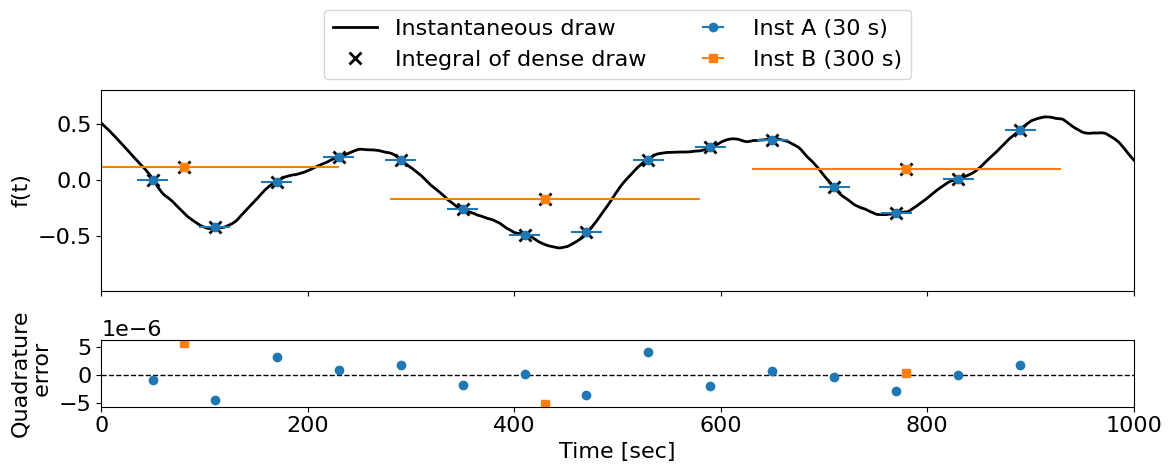

In [9]:
# Let's define the canonical example integrated SHO
S, w, Q = 2.36, 0.0195, 7.63
sigma = jnp.sqrt(S * w * Q)
period = 2 * jnp.pi / w 

# Define this kernel with three instruments, two for two different
# exposure lengths (A & B) and one for the instantaneous grid 
kernel = smolgp.kernels.IntegratedSHO(omega=w, quality=Q, sigma=sigma, num_insts=3)

# Instrument A: short exposures (~10% of the process timescale)
t_A = jnp.arange(50.0, 950.0, 60.0)
texp_A = jnp.full_like(t_A, 30.0)
inst_A = jnp.zeros_like(t_A, dtype=int)

# Instrument B: long exposures (close to the process timescale itself) --
t_B = jnp.arange(80.0, 920.0, 350.0)
texp_B = jnp.full_like(t_B, 300.0)
inst_B = jnp.ones_like(t_B, dtype=int)

# And the instantaneous grid for the dense draw, which will 
# represent the "true" signal we can integrate to verify our samples
t_dense = jnp.linspace(-200.0, 1200.0, 4200)
inst_dense = jnp.full_like(t_dense, 2, dtype=int)

# Combine into a single X_sample
t_all = jnp.concatenate([t_dense, t_A, t_B])
texp_all = jnp.concatenate([jnp.zeros_like(t_dense), texp_A, texp_B])
inst_all = jnp.concatenate([inst_dense, inst_A, inst_B])
X_sample = (t_all, texp_all, inst_all)

# We're drawing a prior sample, so no need to specify an X (data)
# for the gp and then a different X_test for the samples.
gp = smolgp.GaussianProcess(kernel, X=X_sample, noise=0.0)
y_all = gp.sample(subkey)

# Now unpack the samples into A/B/C's draws
n_dense = len(t_dense)
y_dense = y_all[:n_dense]
y_A = y_all[n_dense : n_dense + len(t_A)]
y_B = y_all[n_dense + len(t_A) :]

# Quadrature check: integrate the SAME draw's dense curve over each exposure
def quad_integral(t_c, texp_c):
    tt = jnp.linspace(t_c - texp_c / 2, t_c + texp_c / 2, 200)
    yy = jnp.interp(tt, t_dense, y_dense)
    return jnp.trapezoid(yy, tt) / texp_c

y_quad_A = jax.vmap(quad_integral)(t_A, texp_A)
y_quad_B = jax.vmap(quad_integral)(t_B, texp_B)

# Plot the results
fig, (ax, rax) = plt.subplots(2, 1, figsize=(12, 5), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax.plot(t_dense, y_dense, color="k", lw=2, label="Instantaneous draw")
ax.errorbar(t_A, y_A, xerr=texp_A / 2, fmt="o", color="C0", label="Inst A (30 s)")
ax.errorbar(t_B, y_B, xerr=texp_B / 2, fmt="s", color="C1", label="Inst B (300 s)")
ax.plot(t_A, y_quad_A, "x", color="k", ms=8, mew=2)
ax.plot(t_B, y_quad_B, "x", color="k", ms=8, mew=2, label="Integral of dense draw")
ax.legend(ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1))
ax.set(ylabel="f(t)", xlim=(0, 1000))

rax.axhline(0, color="k", ls="--", lw=1)
rax.plot(t_A, y_A - y_quad_A, "o", color="C0")
rax.plot(t_B, y_B - y_quad_B, "s", color="C1")
rax.set(xlabel="Time [sec]", ylabel="Quadrature\n error")
fig.tight_layout()